<a href="https://colab.research.google.com/github/mooneedg/Credit-Fraud-Prediction/blob/main/Credit_Fraud_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [ ]:
# Manage Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_curve

# 2. Import Data

In [ ]:
%%time
# https://www.kaggle.com/mlg-ulb/creditcardfraud
# Load data
dataset = pd.read_csv('creditcard.csv')

# Print shape
print('Dataset shape', dataset.shape)

Dataset shape (284807, 31)
CPU times: user 4.14 s, sys: 231 ms, total: 4.37 s
Wall time: 7.82 s


In [ ]:
 # Taking a sample to see our data

dataset.sample(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
150529,93609.0,-8.553323,7.694079,-4.527267,-3.343985,0.178842,-1.287124,1.677346,-0.413169,8.294218,...,-1.277278,0.135937,0.109607,0.196831,1.512711,-0.031669,2.529364,0.630107,3.69,0
121010,76042.0,-1.633888,0.318762,0.776941,1.131219,0.345596,-1.169641,0.369027,0.001394,-0.307723,...,0.105515,0.412008,-0.252600,0.420926,-0.243649,-0.372363,-0.094862,-0.057418,40.43,0
166343,118015.0,0.050322,0.402958,0.789783,-0.627845,0.051557,0.049537,0.216446,0.040670,0.492662,...,0.325914,1.031268,-0.081635,0.677562,-0.400256,0.531929,-0.108827,0.006508,27.00,0
235635,148476.0,-1.703063,1.286281,1.687221,2.507807,1.187767,0.962122,1.730863,-0.552693,-1.270861,...,-0.032971,0.449594,-0.407511,-0.385795,0.898644,0.115964,-0.982604,-0.441137,75.00,0
230823,146497.0,2.007844,-0.236030,-1.780973,0.436600,0.280470,-0.693577,0.239017,-0.096142,0.420892,...,0.005447,0.004830,0.107427,0.753279,0.118467,0.329287,-0.109990,-0.078314,23.74,0
211878,138608.0,1.650099,-1.354464,0.217146,0.598816,-0.878420,1.828923,-1.454285,0.570107,2.396786,...,0.189075,0.853739,-0.076855,-0.120291,-0.103302,-0.166888,0.087850,-0.012482,136.13,0
168677,119336.0,-0.525445,1.477400,-0.392693,1.021656,0.522290,-0.783217,1.272833,0.088019,-0.934835,...,0.187284,0.696457,-0.141002,-0.011042,0.091951,-0.374430,0.303062,0.185337,54.84,0
68796,53146.0,1.098029,-0.234761,0.637451,0.798907,-0.633422,0.049548,-0.387962,0.249344,0.558818,...,-0.004532,0.131945,-0.040325,0.259171,0.402027,0.440915,-0.014999,-0.001370,19.99,0
53967,46235.0,-3.507722,3.009356,-0.224012,-1.939991,-0.783111,-0.734802,0.131237,0.565155,1.712345,...,-0.235758,-0.063484,0.161191,0.234051,0.142614,0.719953,0.259529,0.105888,3.76,0
106503,69991.0,-0.973682,-0.446373,2.163724,0.733064,0.096672,-0.108364,-0.557794,0.269943,-1.108954,...,-0.302300,-0.403205,-0.096337,0.040405,0.314492,-0.099353,0.116410,0.094594,11.50,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
dataset.isnull().values.any()

np.False_

In [ ]:
dataset[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


/tmp/ipykernel_9521/3952420914.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  dataClasses = pd.value_counts(dataset['Class'])


<Axes: xlabel='Class'>

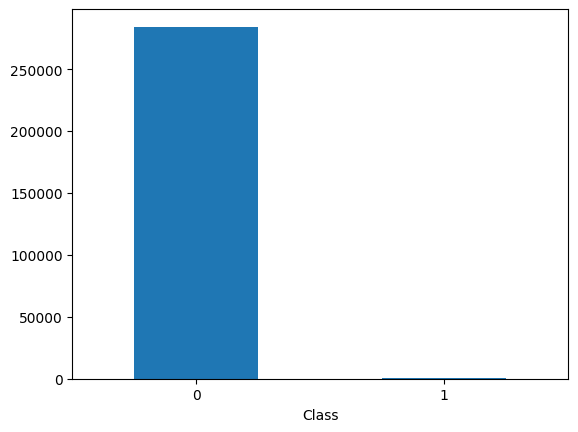

In [ ]:
# Checking the target value balance

dataClasses = pd.value_counts(dataset['Class'])

dataClasses.plot(kind='bar', rot=0)

In [ ]:
fraud = dataset[dataset['Class'] == 1]
valid = dataset[dataset['Class'] == 0]

fraudPer = (len(fraud)/len(valid))*100

print ('Fraud Transactions: ', len (fraud))
print('Valid Transactions: ', len (valid))
print('Fraud Percentage: {}%' .format(round(fraudPer, 3)))

Fraud Transactions:  492
Valid Transactions:  284315
Fraud Percentage: 0.173%


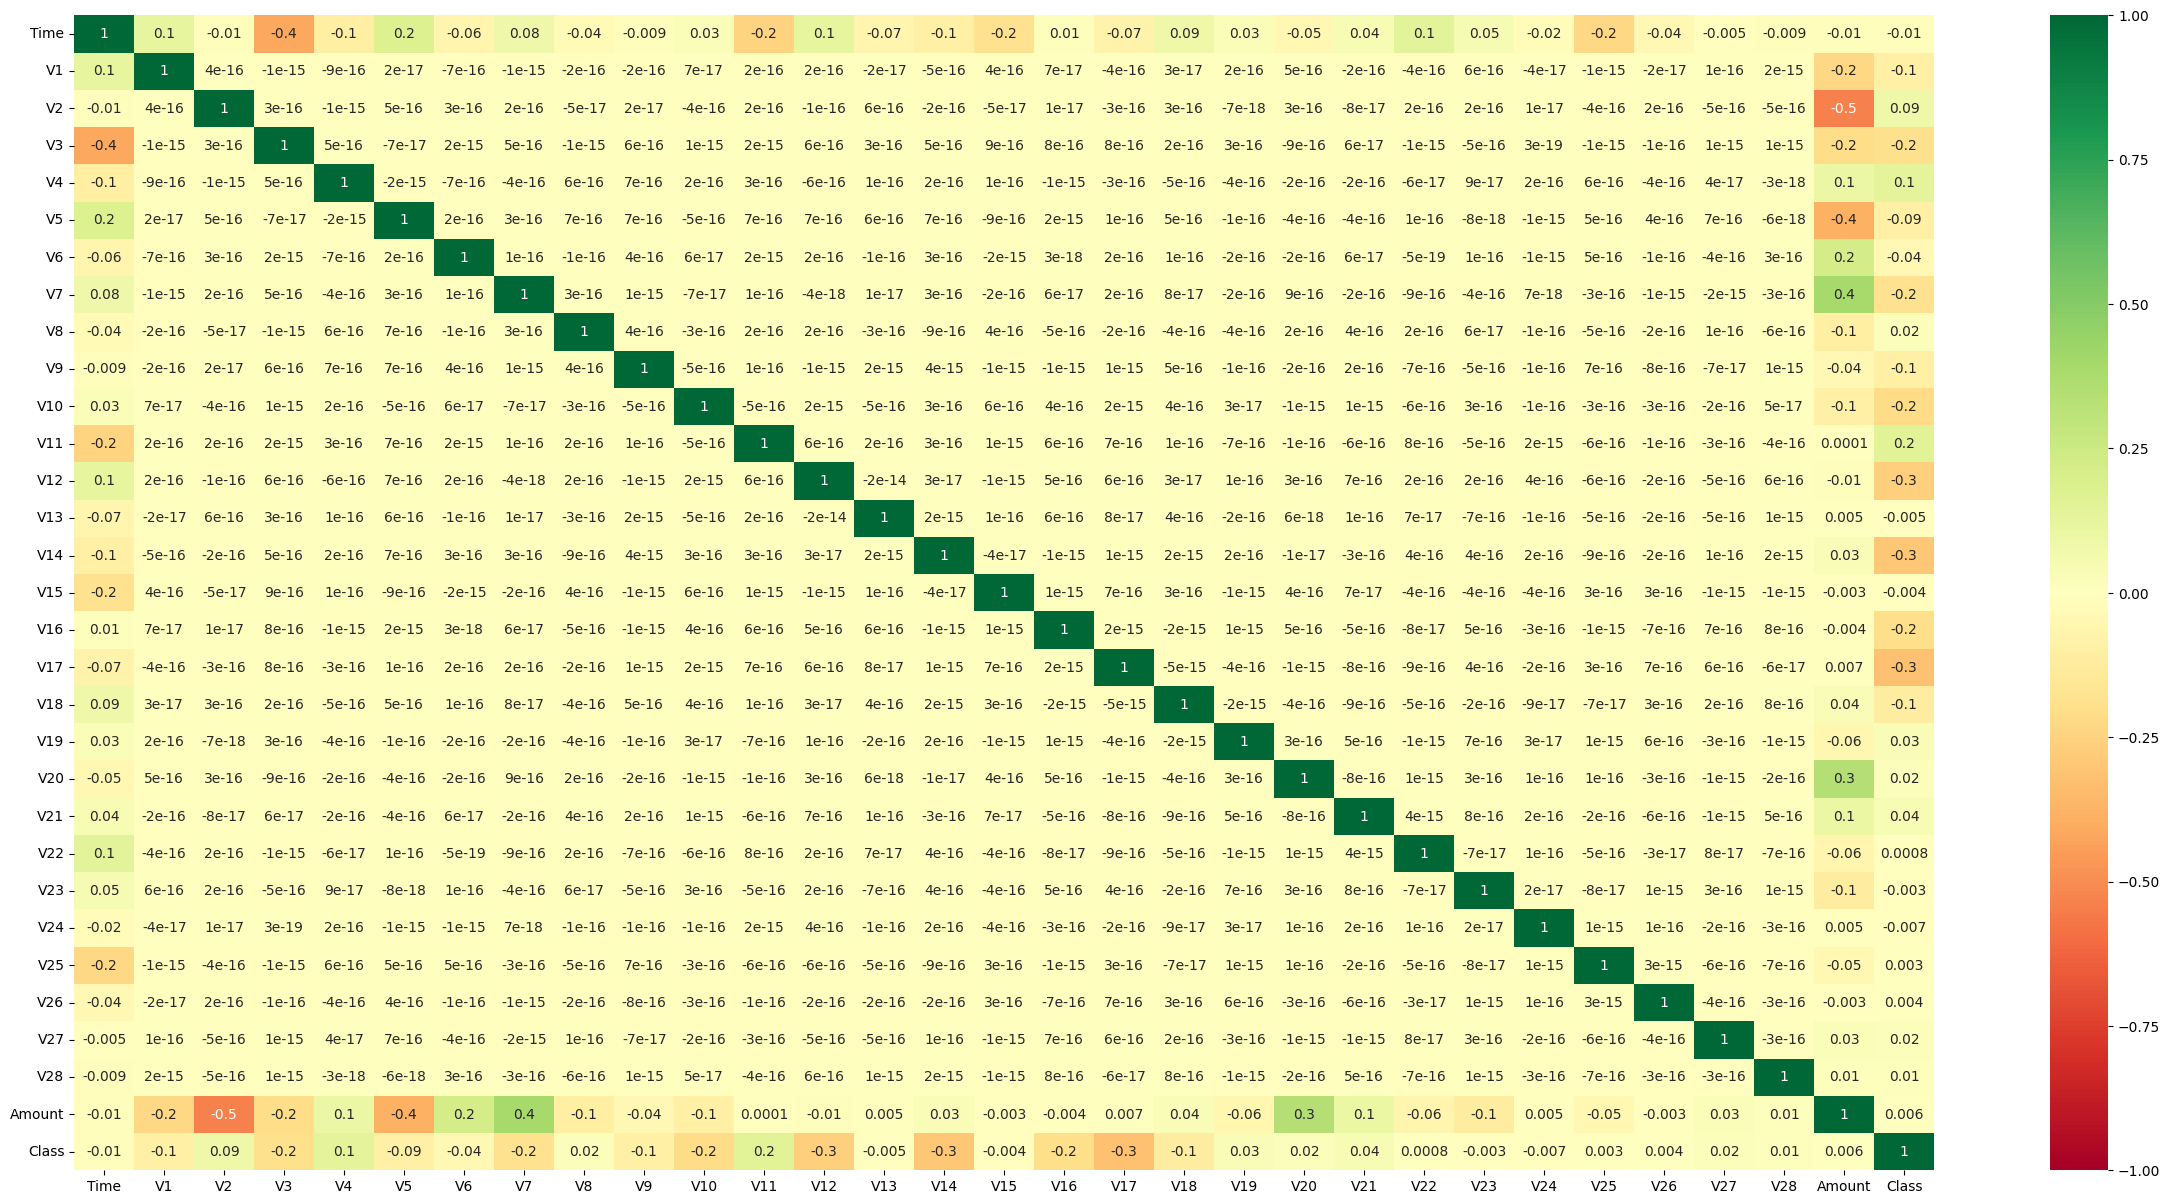

In [ ]:
corr = dataset.corr(method='pearson')

figure = plt.figure(figsize=(30,15))
sns.heatmap(corr, annot=True, fmt = '.1g', vmin = -1, vmax = 1, center = 0, cmap="RdYlGn")
plt.show()

# 3. Prepare Data to Feed the Model

In [ ]:
X = dataset.iloc[:,:-1] # All the dataset until the last column
y = dataset.iloc[:,-1] # Only the Last column

In [ ]:
# Stratify to make sure that each class is represented with approximately equal proportions in both subsets

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Random Forest Classifier

In [ ]:
# Declare the Random Forest Classifier - a group of decision trees
# Ensemble method

RFclassifier = RandomForestClassifier(n_estimators = 100,
                                      criterion = 'gini',
                                      max_depth = None)

In [ ]:
# Passing our training set to the .fit() method

RFclassifier.fit(Xtrain, ytrain)

RandomForestClassifier()

In [ ]:
# Compute class predictions

RFpred = RFclassifier.predict(Xtest)

# 5. Model Evaluation

In [ ]:
# Calculating AUC Score

rf_auroc = roc_auc_score(ytest, RFpred)
print('Random Forest AUCOC: {}' .format(rf_auroc))

Random Forest AUCOC: 0.9081193007591333


In [ ]:
# Calculating FPR, TPR and Tresholds

rf_fpr, rf_tpr, thresholds = roc_curve(ytest, RFpred)

In [ ]:
# Baseline, random vase scenario

random = [0 for _ in range(len(ytest))]

random_auc = roc_auc_score(ytest, random)
random_fpr, random_tpr, thresholds = roc_curve(ytest, random)

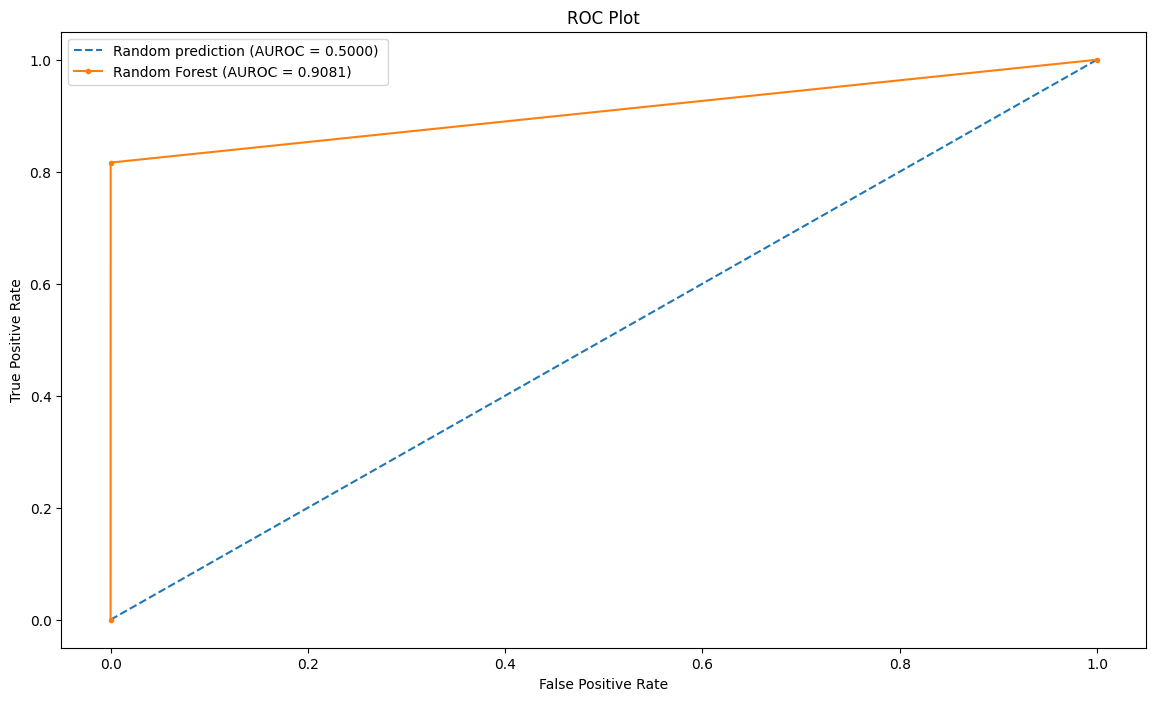

In [ ]:
# Ploting the ROC Curve

figure = plt.figure(figsize=(14,8))
plt.plot(random_fpr, random_tpr, linestyle='--', label= 'Random prediction (AUROC = %0.4f) ' % random_auc)
plt.plot(rf_fpr, rf_tpr, marker='.', label='Random Forest (AUROC = %0.4f) ' % rf_auroc)

plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

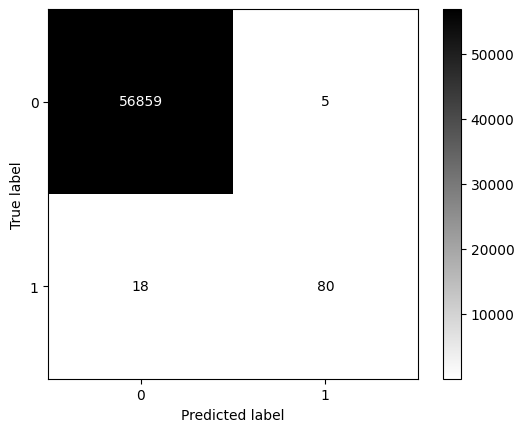

In [ ]:
# Plot Confusion Matrix

ConfusionMatrixDisplay.from_estimator(
    RFclassifier,
    Xtest,
    ytest,
    cmap='binary'
)

In [ ]:
precision = precision_score(ytest, RFpred)
recall = recall_score(ytest, RFpred)

print('Precision: {}' .format(precision)) # The ratio of positive instances (frauds) predictions that were precise
print('Recall: {}' .format(recall)) # The ratio of positive instances (frauds) correctly classified by the model

Precision: 0.9411764705882353
Recall: 0.8163265306122449


In [ ]:
precisions, recalls, thresholds = precision_recall_curve(ytest, RFpred)

In [ ]:
def plot_PR_curve(precisions, recalls):
  figure = plt.figure(figsize=(14,8))
  plt.plot(recalls, precisions, "b--", label='PR Curve')
  plt.title('Precision vs Recall Plot')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.legend()
  plt.show()

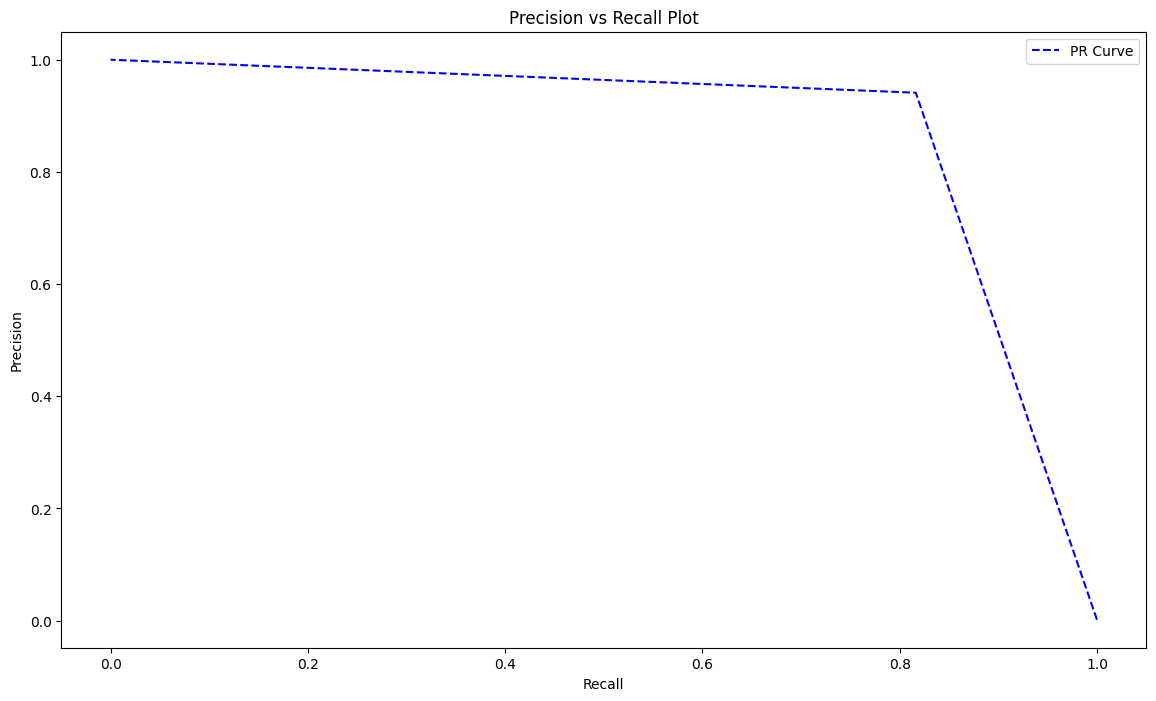

In [ ]:
plot_PR_curve(precisions, recalls)

# 6. Results

AUROC: 0.9081

Precision: 0.9411764705882353

Recall: 0.8163265306122449